# Task 2 — Feature Engineering

**Goal:** Understand the feature space, separate features from labels, apply `StandardScaler` (required for SVC), and save the processed arrays for model training.

**Input:** `data/processed/compounds_clean.csv`  
**Output:** `data/processed/X_scaled.npy`, `y.npy`, `cid.npy`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/compounds_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (243, 313)


,CID,Class,PUBCHEM_XLOGP3_AA,PUBCHEM_EXACT_MASS,PUBCHEM_MOLECULAR_WEIGHT,PUBCHEM_CACTVS_TPSA,PUBCHEM_MONOISOTOPIC_WEIGHT,PUBCHEM_HEAVY_ATOM_COUNT,PUBCHEM_ATOM_DEF_STEREO_COUNT,PUBCHEM_ATOM_UDEF_STEREO_COUNT,...,vsurf_Wp3,vsurf_Wp4,vsurf_Wp5,vsurf_Wp6,vsurf_Wp7,vsurf_Wp8,Weight,weinerPath,weinerPol,zagreb
0,11574718,0,3.1000,393.1689,393.4357,81.7000,393.1689,29,0,0,...,113.5000,23.8750,7.3750,0.2500,0.0000,0.0000,393.4430,2450,45,146
1,11588394,0,2.0000,353.1375,353.3719,81.2000,353.1375,26,0,0,...,112.2500,27.2500,8.7500,1.6250,0.0000,0.0000,353.3780,1786,41,132
2,11595532,0,2.9000,353.1375,353.3719,85.7000,353.1375,26,0,0,...,101.5000,22.1250,6.5000,0.3750,0.0000,0.0000,353.3780,1767,41,132
3,11603925,0,3.5000,409.1638,409.4351,91.8000,409.1638,30,0,0,...,94.7500,15.3750,5.0000,0.3750,0.0000,0.0000,409.4420,2694,48,150
4,11624721,0,3.0000,362.1379,362.3819,89.3000,362.1379,27,0,0,...,98.7500,15.7500,5.0000,0.3750,0.0000,0.0000,362.3890,1976,43,136


## 2. Inspect Feature Groups

The 311 features come from several descriptor families computed by MOE and PubChem:

In [3]:
feature_cols = [c for c in df.columns if c not in ['CID', 'Class']]

# Group by prefix (the part before the first underscore, or 'other' if no underscore)
from collections import Counter
prefix_counts = Counter(c.split('_')[0] if '_' in c else 'other' for c in feature_cols)
group_df = pd.DataFrame(prefix_counts.most_common(), columns=['prefix', 'count'])

# Annotate families
family_map = {
    'vsurf':   'VolSurf surface descriptors',
    'other':   'MOE physicochemical (ungrouped)',
    'PEOE':    'Partial Equalization of Orbital Electronegativity (charge)',
    'a':       'Atom-count descriptors',
    'E':       'Energy descriptors',
    'BCUT':    'BCUT eigenvalue descriptors',
    'GCUT':    'GCUT eigenvalue descriptors',
    'b':       'Bond-count descriptors',
    'PUBCHEM': 'PubChem computed properties',
    'SlogP':   'SlogP surface area contributions',
    'SMR':     'SMR molar refractivity contributions',
    'AM1':     'AM1 semi-empirical quantum chemistry',
    'MNDO':    'MNDO semi-empirical quantum chemistry',
    'PM3':     'PM3 semi-empirical quantum chemistry',
    'vsa':     'Van der Waals surface area',
    'opr':     'Other property descriptors',
    'ast':     'Accessible surface area/topology',
    'lip':     'Lipinski rule-of-five related',
    'std':     'Standard deviation descriptors',
}
group_df['family'] = group_df['prefix'].map(lambda p: family_map.get(p, ''))
print(f'Total features: {len(feature_cols)}')
print()
print(group_df.to_string(index=False))

Total features: 311

 prefix  count                                                     family
  vsurf     76                                VolSurf surface descriptors
  other     55                            MOE physicochemical (ungrouped)
   PEOE     30 Partial Equalization of Orbital Electronegativity (charge)
      a     20                                     Atom-count descriptors
      E     13                                         Energy descriptors
   BCUT     12                                BCUT eigenvalue descriptors
   GCUT     12                                GCUT eigenvalue descriptors
      b     11                                     Bond-count descriptors
PUBCHEM     10                                PubChem computed properties
  SlogP     10                           SlogP surface area contributions
    SMR      8                       SMR molar refractivity contributions
    AM1      7                       AM1 semi-empirical quantum chemistry
   MNDO      7   

## 3. Separate X, y, and CID

In [4]:
cid = df['CID'].values
y   = df['Class'].values
X   = df[feature_cols].values

print(f'X shape : {X.shape}  (compounds × features)')
print(f'y shape : {y.shape}  — classes: {np.unique(y)}')
print(f'cid shape: {cid.shape}')
print()
print('Class counts:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls} → {cnt} ({cnt/len(y)*100:.1f}%)')

X shape : (243, 311)  (compounds × features)
y shape : (243,)  — classes: [0 1]
cid shape: (243,)

Class counts:
  0 → 72 (29.6%)
  1 → 171 (70.4%)


## 4. Feature Scaling

SVC with an RBF kernel computes distances between feature vectors. Features on very different scales (e.g., molecular weight ~400 vs. a binary flag 0/1) will dominate the distance calculation and bias the classifier. `StandardScaler` transforms each feature to zero mean and unit variance, putting all descriptors on equal footing.

In [5]:
# Fit scaler on the full dataset (train/test split happens in Task 4)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling:')
print(f'  mean range : [{X.mean(axis=0).min():.3f}, {X.mean(axis=0).max():.3f}]')
print(f'  std  range : [{X.std(axis=0).min():.3f}, {X.std(axis=0).max():.3f}]')
print()
print('After scaling:')
print(f'  mean range : [{X_scaled.mean(axis=0).min():.6f}, {X_scaled.mean(axis=0).max():.6f}]')
print(f'  std  range : [{X_scaled.std(axis=0).min():.6f}, {X_scaled.std(axis=0).max():.6f}]')

Before scaling:
  mean range : [-1034307.286, 35025.439]
  std  range : [0.000, 386273.209]

After scaling:
  mean range : [-0.000000, 0.000000]
  std  range : [1.000000, 1.000000]


## 5. Feature Value Distribution

Distribution of scaled feature values across all compounds — should be centered near 0 with most values within ±3.

/var/folders/cp/29s94x0s7c71s6_qytw80tf00000gn/T/ipykernel_21730/2977681546.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, i] for i in sample_idx],


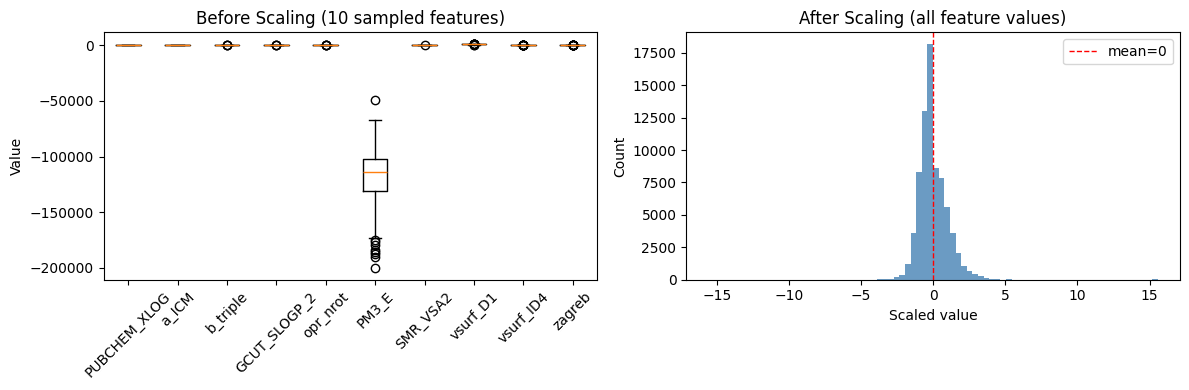

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling — sample 10 features for readability
sample_idx = np.linspace(0, X.shape[1] - 1, 10, dtype=int)
axes[0].boxplot([X[:, i] for i in sample_idx],
                labels=[feature_cols[i][:12] for i in sample_idx],
                vert=True)
axes[0].set_title('Before Scaling (10 sampled features)')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

# After scaling — distribution of all values flattened
axes[1].hist(X_scaled.ravel(), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title('After Scaling (all feature values)')
axes[1].set_xlabel('Scaled value')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='mean=0')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/feature_scaling.png', dpi=150)
plt.show()

## 6. Save Processed Arrays

In [7]:
np.save('../data/processed/X_scaled.npy', X_scaled)
np.save('../data/processed/y.npy', y)
np.save('../data/processed/cid.npy', cid)

print('Saved:')
print(f'  data/processed/X_scaled.npy  {X_scaled.shape}')
print(f'  data/processed/y.npy         {y.shape}')
print(f'  data/processed/cid.npy       {cid.shape}')

Saved:
  data/processed/X_scaled.npy  (243, 311)
  data/processed/y.npy         (243,)
  data/processed/cid.npy       (243,)
